<a href="https://colab.research.google.com/github/nthambire/p-s_pucrj.ciencia-de-dados/blob/main/MVP_Breast_Cancer_ML_Analytics_20261.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Nthambire Rodrigues Sabonete

**Matrícula:** _4052026000285_  
**Data:** _05/07/2026_  
**Dataset:** _Breast Cancer Wisconsin (Diagnostic) Dataset (link:  [kaggle.com/datasets/yasserh/breast-cancer-dataset](https://www.kaggle.com/datasets/yasserh/breast-cancer-dataset))_  
**Tipo de problema:** _Classificação_  

## Checklist do MVP

Use este checklist antes da entrega.

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ☐ |
| Dataset descrito, com fonte, atributos e restrições | ☐ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ☐ |
| Análise exploratória objetiva, conectada à modelagem | ☐ |
| Divisão adequada em treino/teste e, se aplicável, validação | ☐ |
| Prevenção de vazamento de dados | ☐ |
| Tratamentos de dados justificados | ☐ |
| Pipeline ou sequência reprodutível de pré-processamento | ☐ |
| Modelo baseline definido | ☐ |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ☐ |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ☐ |
| Avaliação com métricas coerentes com o problema | ☐ |
| Discussão de overfitting/underfitting, limitações e melhorias | ☐ |
| Código limpo, organizado e executável do início ao fim | ☐ |
| Conclusão conectada ao objetivo inicial | ☐ |

> **Comentário:** nem todo item se aplica igualmente a todos os tipos de problema. Por exemplo, clusterização pode não ter target; séries temporais exigem divisão temporal; deep learning e fine-tuning são opcionais.


# 1. Definição do problema

## 1.1 Descrição do problema

O diagnóstico de um cancêr depende de análises detalhadas de exames clínicos, laboratoriais, imagens e biópsias, e o diganóstico quando mais cedo maior a porcentagem de um tratamento efetivo.


O diagnóstico precoce da doença possibilita que, com a descoberta em um estágio mais inicial, potencialmente curável, sejam utilizadas terapias mais simples e efetivas, ajudando na redução do estágio e melhorando a sobrevivência e a qualidade de vida do indivíduo.
Com isso, o objetivo deste código é classificar tumores com uma alta precisão, ajudando o médico responsável a ter maior efetividade no diagnóstico e para que o diagnpostico seja mais rápido e menos invasivo para o paciente, permitindo o início mais rápido do tratamento.



>Fonte de apoio: [Detecção Precoce - Instituto Nacional de Câncer - INCA
](https://www.inca.gov.br/sites/ufu.sti.inca.local/files/media/document/deteccao-precoce-do-cancer_0.pdf)


## 1.2 Objetivo do MVP

O objetivo deste MVP é desenvolver e avaliar um modelo de Machine Learning para classificação binária capaz de identificar de forma automatizada se um tumor de mama é maligno ou benigno a partir de características morfológicas celulares. Com isso, busca-se otimizar a métrica de *Recall* para fornecer aos oncologistas uma ferramenta ágil e segura de triagem secundária, apoiando o diagnóstico precoce e preciso da doença.

## 1.3 Tipo de problema

**Tipo escolhido:** _classificação_  
**Justificativa:** _este modelo busca prever uma variável categórica (benigno ou maligno)_

## 1.4 Premissas, hipóteses e critérios de sucesso

Liste as principais hipóteses e como você pretende verificar se o MVP foi bem-sucedido.

**Hipóteses iniciais:**
1. _Hipótese 1:_ atributos que medem tamanho e irregularidade da célula (`radius_worst`, `perimeter_worst` e `area_worst`) são maiores em tumores malignos, permitindo o uso mair efetivo de modelos lineares de de margem;
2. _Hipótese 2:_ o uso de padronização aumentará a precisão e a convergência de modelos baseados em distânica (KNN) e gradiente (regressão logística);
3. _Hipótese 3:_ algoritmos cbaseados em árvore de decisão empilhadas capturarão melhor as interações não lineares dos dados sem sofrem com *overfitting*.

**Critérios de sucesso:**
- _Métrica principal:_ Recall dos dos tumores classificados como **malignos**, priorizando a redução de **falsos negativos** (avaliação em conjunto com *F1-score*).
- _Resultado mínimo esperado:_ Alcançar Recall mínimo de 90% na base de teste e superar o baseline em pelo menos 10%.
- _Restrição prática:_ um código simples e com baixo custo computacional, garantindo que o pipeline seja leve e rápido para que seja utilizado em computadores simples como os utilizados em clínicas médicas.


# 2. Ambiente, bibliotecas e reprodutibilidade


In [ ]:

import os
import sys
import time
import glob
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub



from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, TimeSeriesSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)
from scipy.stats import randint

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)


Python: 3.12.13
Seed: 42


## 2.2 Funções auxiliares




In [ ]:
def evaluate_classification(y_true, y_pred, proba=None):
    """Calcula métricas básicas para classificação."""
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted")
    }

    # ROC AUC é mais direto para classificação binária com probabilidades.
    try:
        if proba is not None and proba.shape[1] == 2:
            results["roc_auc"] = roc_auc_score(y_true, proba[:, 1])
        else:
            results["roc_auc"] = np.nan
    except Exception:
        results["roc_auc"] = np.nan

    return results


def evaluate_regression(y_true, y_pred):
    """Calcula métricas básicas para regressão."""
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }


def show_results_table(results_dict):
    """Exibe resultados como DataFrame ordenável."""
    return pd.DataFrame(results_dict).T


# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

Descrição da base escolhida.

- nome do dataset:  Breast Cancer Wisconsin (Diagnostic) Dataset
- link da fonte: [kaggle.com/datasets/yasserh/breast-cancer-dataset](https://kaggle.com/datasets/yasserh/breast-cancer-dataset)
- por que esse dataset foi escolhido: este dataset tem uma taxa alta deutilização no kaggle, póssui uma alta usabilidade por ter um detalhamento na descrição dos dados.
- quais restrições ou condições foram consideradas: este dataset possui apenas 569 instâncias, (exigindo validação cruzada estratificada para evitar overfitting), além de apresentar um desbalanceamento de classes (63% Benignos / 37% Malignos)
- questões de ética, privacidade, confidencialidade ou licença: os dados foram totalmente anonimizados na origem, respeitando a privacidade dos pacientes. O uso deste modelo é consultivo e não substitui laudos médicos que são soberanos. A base está sob a licença CC BY-NC-SA 4.0, permitindo o uso livre para fins acadêmicos e de estudo (como este MVP).


## 3.2 Carga dos dados



In [ ]:

path = kagglehub.dataset_download("yasserh/breast-cancer-dataset")
print("Path do dataset:", path)

csv_files = glob.glob(os.path.join(path, "*.csv"))

if csv_files:
    df_path = csv_files[0]
    print(f"Carregando o arquivo: {os.path.basename(df_path)}")

    raw_data = pd.read_csv(df_path)
    df = raw_data.copy()

    df.rename(columns={df.columns[-1]: "diagnosis"}, inplace=True)

    print("Dados carregados com sucesso.")
else:
    print("Erro: Nenhum arquivo CSV foi encontrado.")

df.head()

Using Colab cache for faster access to the 'breast-cancer-dataset' dataset.
Path do dataset: /kaggle/input/breast-cancer-dataset
Carregando o arquivo: breast-cancer.csv
Dados carregados com sucesso.


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,diagnosis
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3.3 Visão geral do dataset


- quantidade de linhas e colunas;
- tipos dos atributos;
- valores ausentes;
- duplicatas;
- possíveis colunas de ID, data ou variáveis que não devem entrar no modelo;
- descrição do target, se houver.


In [ ]:
# Inspeção, Estrutura e Governança dos Dados

print("-" * 60)
print("1. DIMENSÕES DO DATASET")
print("-" * 60)
print(f"Quantidade de Linhas:  {df.shape[0]}")
print(f"Quantidade de Colunas: {df.shape[1]}")

# --- START FIX ---
# Remove duplicate columns, keeping the first occurrence.
# This assumes the first 'diagnosis' column (index 1) is the correct one (M/B).
df = df.loc[:,~df.columns.duplicated(keep='first')]
print("✅ Colunas duplicadas (se houver) foram tratadas, mantendo a primeira ocorrência.")
# --- END FIX ---


print("\n" + "-" * 60)
print("2. TIPOS DOS ATRIBUTOS + VALORES AUSENTES ")
print("-" * 60)
info_df = pd.DataFrame({
    'Tipo de Dado': df.dtypes,
    'Valores Ausentes (Qtd)': df.isnull().sum(),
    'Valores Ausentes (%)': ((df.isnull().sum() / len(df)) * 100).round(2)
})
display(info_df) # No Colab, display() renderiza a tabela de forma mais bonita que print()

print("\n" + "-" * 60)
print("3. VERIFICAÇÃO DE DUPLICATAS")
print("-" * 60)
total_duplicadas = df.duplicated().sum()
print(f"Quantidade de linhas totalmente duplicadas: {total_duplicadas}")

print("\n" + "-" * 60)
print("4. ANÁLISE DE IDENTIFICADORES (IDs) OU VARIÁVEIS IRRELEVANTES")
print("-" * 60)
colunas_id = [col for col in df.columns if 'id' in col.lower() or 'index' in col.lower()]
if colunas_id:
    print(f"⚠️ Atenção: Colunas identificadas como possíveis IDs/Identificadores: {colunas_id}")
    print("💡 Recomendação técnica: Remover estas colunas antes do treinamento (ex: df.drop(columns=...)),")
    print("   pois não agregam valor preditivo e podem causar overfitting se mantidas.")
else:
    print("Nenhuma coluna óbvia de ID ou data foi mapeada por padrão de nome.")

print("\n" + "-" * 60)
print("5. DESCRIÇÃO DA VARIÁVEL ALVO (TARGET)")
print("-" * 60)
coluna_target = 'diagnosis'  # Nome padrão da variável alvo neste dataset

if coluna_target in df.columns:
    print(f"Nome da variável alvo: '{coluna_target}'")

    # Mapeamento estético para exibir os significados reais das siglas ('M' e 'B')
    contagem_absoluta = df[coluna_target].value_counts()
    contagem_percentual = (df[coluna_target].value_counts(normalize=True) * 100).round(2)

    # Criando um DataFrame consolidado para o Target
    target_summary = pd.DataFrame({
        'Contagem Absoluta': contagem_absoluta,
        'Percentual (%)': contagem_percentual
    })

    # Se as classes forem 'M' e 'B', renomeia o índice para facilitar a leitura do professor
    if set(target_summary.index).issubset({'M', 'B'}):
        target_summary.rename(index={'M': 'M (Maligno)', 'B': 'B (Benigno)'}, inplace=True)

    display(target_summary)

    # Nota técnica sobre balanceamento
    print("\n💡 Observação sobre o balanceamento:")
    print("As classes estão relativamente bem distribuídas (perto de 60/40), o que é excelente para classificação,")
    print("não exigindo necessariamente técnicas severas de balanceamento como SMOTE.")
else:
    print(f"❌ Alerta: A coluna target esperada '{coluna_target}' não foi encontrada no DataFrame.")

------------------------------------------------------------
1. DIMENSÕES DO DATASET
------------------------------------------------------------
Quantidade de Linhas:  569
Quantidade de Colunas: 32
✅ Colunas duplicadas (se houver) foram tratadas, mantendo a primeira ocorrência.

------------------------------------------------------------
2. TIPOS DOS ATRIBUTOS + VALORES AUSENTES 
------------------------------------------------------------


,Tipo de Dado,Valores Ausentes (Qtd),Valores Ausentes (%)
id,int64,0,0.0
diagnosis,object,0,0.0
radius_mean,float64,0,0.0
texture_mean,float64,0,0.0
perimeter_mean,float64,0,0.0
area_mean,float64,0,0.0
smoothness_mean,float64,0,0.0
compactness_mean,float64,0,0.0
concavity_mean,float64,0,0.0
concave points_mean,float64,0,0.0



------------------------------------------------------------
3. VERIFICAÇÃO DE DUPLICATAS
------------------------------------------------------------
Quantidade de linhas totalmente duplicadas: 0

------------------------------------------------------------
4. ANÁLISE DE IDENTIFICADORES (IDs) OU VARIÁVEIS IRRELEVANTES
------------------------------------------------------------
⚠️ Atenção: Colunas identificadas como possíveis IDs/Identificadores: ['id']
💡 Recomendação técnica: Remover estas colunas antes do treinamento (ex: df.drop(columns=...)),
   pois não agregam valor preditivo e podem causar overfitting se mantidas.

------------------------------------------------------------
5. DESCRIÇÃO DA VARIÁVEL ALVO (TARGET)
------------------------------------------------------------
Nome da variável alvo: 'diagnosis'


,Contagem Absoluta,Percentual (%)
diagnosis,,
B (Benigno),357,62.74
M (Maligno),212,37.26



💡 Observação sobre o balanceamento:
As classes estão relativamente bem distribuídas (perto de 60/40), o que é excelente para classificação,
não exigindo necessariamente técnicas severas de balanceamento como SMOTE.


## 3.4 Dicionário de dados



In [ ]:

atributos_dados = {
    "Coluna": [
        "id",
        "radius_mean / _se / _worst",
        "texture_mean / _se / _worst",
        "perimeter_mean / _se / _worst",
        "area_mean / _se / _worst",
        "smoothness_mean / _se / _worst",
        "compactness_mean / _se / _worst",
        "concavity_mean / _se / _worst",
        "concave points_mean / _se / _worst",
        "symmetry_mean / _se / _worst",
        "fractal_dimension_mean / _se / _worst",
        "diagnosis"
    ],
    "Tipo": [
        "numérica (inteiro)",
        "numérica (contínuo)",
        "numérica (contínuo)",
        "numérica (contínuo)",
        "numérica (contínuo)",
        "numérica (contínuo)",
        "numérica (contínuo)",
        "numérica (contínuo)",
        "numérica (contínuo)",
        "numérica (contínuo)",
        "numérica (contínuo)",
        "alvo (categórica)"
    ],
    "Descrição": [
        "Código identificador exclusivo de cada paciente.",
        "Raio (média das distâncias do centro aos pontos do perímetro do núcleo).",
        "Textura (desvio padrão dos valores na escala de cinza dos píxeis).",
        "Tamanho total do perímetro do núcleo celular.",
        "Área espacial ocupada pelo núcleo da célula.",
        "Suavidade (variação local nos comprimentos dos raios).",
        "Compacidade (perímetro² / área - 1.0).",
        "Severidade das secções côncavas no contorno do núcleo.",
        "Quantidade de porções côncavas no contorno celular.",
        "Índice de simetria geométrica do núcleo.",
        "Dimensão fractal (aproximação da complexidade da borda).",
        "Diagnóstico clínico do tumor mapeado."
    ],
    "Será usada no modelo?": [
        "não", "sim", "sim", "sim", "sim", "sim", "sim", "sim", "sim", "sim", "sim", "alvo"
    ],
    "Observações": [
        "Deve ser descartada; não possui poder preditivo e causaria sobreajuste.",
        "O valor '_worst' possui forte peso na separação de malignidade.",
        "Atributo importante para capturar irregularidades na superfície celular.",
        "Altamente correlacionado com o raio e a área (redundância geométrica).",
        "Possui escala numérica muito superior, exigindo padronização obrigatória.",
        "Valores baixos e alta irregularidade costumam indicar tumores malignos.",
        "Modela quão densa ou dispersa a estrutura do núcleo se apresenta.",
        "Indica a presença de deformações estruturais profundas na membrana.",
        "Mede o número absoluto de depressões e não a severidade delas.",
        "Células cancerígenas tendem a perder a simetria natural ao se multiplicarem.",
        "Avalia o nível de fragmentação periférica do núcleo da célula.",
        "Classe prevista: M (Maligno) ou B (Benigno). Será convertida para 1 ou 0."
    ]
}

df_atributos = pd.DataFrame(atributos_dados)
df_atributos.style.set_properties(**{'text-align': 'left'}).hide(axis='index')

Coluna,Tipo,Descrição,Será usada no modelo?,Observações
id,numérica (inteiro),Código identificador exclusivo de cada paciente.,não,Deve ser descartada; não possui poder preditivo e causaria sobreajuste.
radius_mean / _se / _worst,numérica (contínuo),Raio (média das distâncias do centro aos pontos do perímetro do núcleo).,sim,O valor '_worst' possui forte peso na separação de malignidade.
texture_mean / _se / _worst,numérica (contínuo),Textura (desvio padrão dos valores na escala de cinza dos píxeis).,sim,Atributo importante para capturar irregularidades na superfície celular.
perimeter_mean / _se / _worst,numérica (contínuo),Tamanho total do perímetro do núcleo celular.,sim,Altamente correlacionado com o raio e a área (redundância geométrica).
area_mean / _se / _worst,numérica (contínuo),Área espacial ocupada pelo núcleo da célula.,sim,"Possui escala numérica muito superior, exigindo padronização obrigatória."
smoothness_mean / _se / _worst,numérica (contínuo),Suavidade (variação local nos comprimentos dos raios).,sim,Valores baixos e alta irregularidade costumam indicar tumores malignos.
compactness_mean / _se / _worst,numérica (contínuo),Compacidade (perímetro² / área - 1.0).,sim,Modela quão densa ou dispersa a estrutura do núcleo se apresenta.
concavity_mean / _se / _worst,numérica (contínuo),Severidade das secções côncavas no contorno do núcleo.,sim,Indica a presença de deformações estruturais profundas na membrana.
concave points_mean / _se / _worst,numérica (contínuo),Quantidade de porções côncavas no contorno celular.,sim,Mede o número absoluto de depressões e não a severidade delas.
symmetry_mean / _se / _worst,numérica (contínuo),Índice de simetria geométrica do núcleo.,sim,Células cancerígenas tendem a perder a simetria natural ao se multiplicarem.


# 4. Análise exploratória dos dados

A análise exploratória deve ser objetiva e conectada ao problema.

**O que incluir:**
- distribuição do target;
- distribuição de variáveis importantes;
- relação entre variáveis e target;
- identificação de desbalanceamento, outliers ou padrões relevantes;
- hipóteses que surgem a partir dos dados.

> **Comentário:** siga a lógica do MVP de pré-processamento: não basta mostrar gráfico; escreva abaixo dele o que o gráfico indica e como isso influencia a modelagem.


In [ ]:
# Ajuste das variáveis conforme o dataset do MVP
TARGET = "diagnosis"
PROBLEM_TYPE = "classificacao"

if TARGET is not None and TARGET in df.columns:
    print("Distribuição do target (0 = Benigno, 1 = Maligno):")
    display(df[TARGET].value_counts(dropna=False).to_frame("contagem"))
    display((df[TARGET].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("percentual"))

Distribuição do target (0 = Benigno, 1 = Maligno):


,contagem
diagnosis,
B,357
M,212


,percentual
diagnosis,
B,62.74
M,37.26


In [ ]:
# Separação de colunas numéricas e categóricas
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

# Remove o target da lista de atributos para a visualização
if TARGET in numeric_cols:
    numeric_cols_without_target = [c for c in numeric_cols if c != TARGET]
else:
    numeric_cols_without_target = numeric_cols





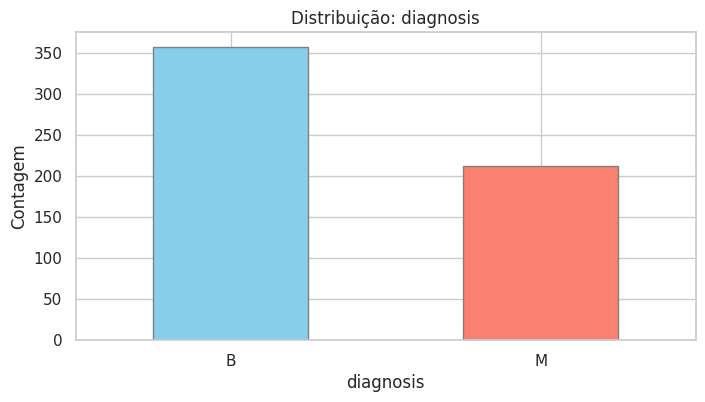

In [ ]:
# Se houver colunas categóricas adicionais, exibe o gráfico de barras
if categorical_cols:
    col = categorical_cols[0]
    plt.figure(figsize=(8, 4))

    # Obtém a contagem de valores para definir as barras
    counts = df[col].value_counts()

    # Define as cores dinamicamente: 'skyblue' para Benigno (B) e 'salmon' para Maligno (M)
    cores_barras = ['skyblue' if x == 'B' else 'salmon' for x in counts.index]

    # Plota o gráfico aplicando a lista de cores correspondente
    counts.plot(kind="bar", color=cores_barras, edgecolor="grey")

    plt.title(f"Distribuição: {col}")
    plt.xlabel(col)
    plt.ylabel("Contagem")
    plt.xticks(rotation=0)  # Deixei em 0 já que os rótulos 'B' e 'M' são curtos e ficam mais legíveis retos
    plt.show()

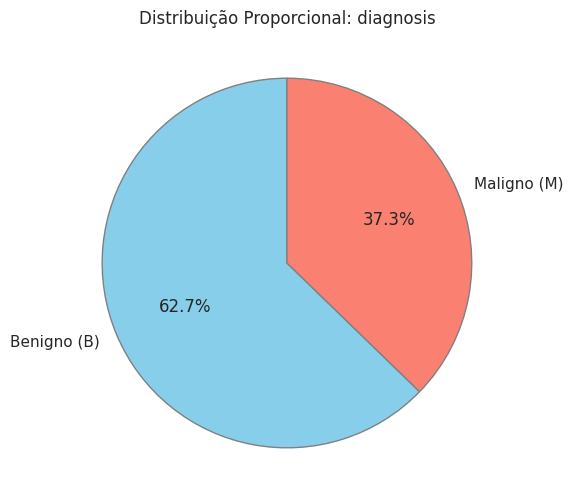

In [ ]:
if TARGET in df.columns:
    plt.figure(figsize=(6, 6))

    # Coleta a contagem e mapeia os nomes de M e B para exibição clara no gráfico
    target_counts = df[TARGET].value_counts()
    labels_mapeados = [ 'Maligno (M)' if x == 'M' else 'Benigno (B)' for x in target_counts.index]

    # Cores personalizadas: Salmon para Maligno e Skyblue para Benigno
    cores = ['salmon' if x == 'M' else 'skyblue' for x in target_counts.index]

    # Plota o gráfico de pizza
    plt.pie(
        target_counts,
        labels=labels_mapeados,
        autopct='%1.1f%%',
        startangle=90,
        colors=cores,
        wedgeprops={'edgecolor': 'grey', 'linewidth': 1}
    )
    plt.title(f"Distribuição Proporcional: {TARGET}")
    plt.show()

## 4.1 Síntese da análise exploratória

Escreva aqui os principais achados da EDA.

**Exemplo de perguntas para responder:**
- O target está balanceado?
- Existem valores ausentes relevantes?
- Há variáveis com escala muito diferente?
- Há categorias raras?
- Existem padrões que sugerem quais modelos podem funcionar melhor?
- Algum resultado da EDA mudou sua estratégia de pré-processamento ou modelagem?

**Síntese:**  
> _Preencha aqui._

O target apresenta um desbalanceamento, sendo a proporção entre tumores benignos e malignos (62.74% vs. 37.26%).


# 5. Preparação dos dados e divisão treino/teste

Nesta etapa, defina claramente quais colunas serão utilizadas, qual é o target e como os dados serão divididos.

**O que incluir:**
- separação entre features e target;
- remoção de colunas que não devem ser usadas;
- divisão treino/teste;
- validação, quando aplicável;
- justificativa para a divisão escolhida.

> **Comentário:** para problemas temporais, não embaralhe os dados. Use divisão baseada no tempo.


In [ ]:
# === 5. Construção dos Pipelines de Pré-processamento ===
# Como todas as features deste dataset são numéricas (raio, perímetro, área, etc.),
# utilizaremos o StandardScaler para normalizar as escalas (essencial para Regressão Logística e SVM)
numeric_features = X.columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Prevenção para dados nulos
    ('scaler', StandardScaler())                  # Padronização (Média 0, Variância 1)
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ]
)

NameError: name 'X' is not defined

## 5.1 Justificativa da divisão

Explique por que a divisão escolhida é adequada.

**O que comentar:**
- Por que usar holdout, validação cruzada ou divisão temporal?
- A proporção treino/teste faz sentido para o tamanho do dataset?
- Foi necessário estratificar as classes?
- Como a divisão evita vazamento de dados?

**Resposta:**  
> _Preencha aqui._


# 6. Pré-processamento e pipeline

Crie uma sequência reprodutível de tratamento dos dados.

**Possíveis etapas:**
- imputação de valores ausentes;
- normalização ou padronização;
- encoding de variáveis categóricas;
- seleção de atributos;
- engenharia de atributos;
- tratamento de texto, imagem ou séries temporais, quando aplicável.

> **Comentário:** sempre que possível, ajuste transformações apenas no treino e aplique no teste. Pipelines ajudam a evitar vazamento de dados.


In [ ]:
# === 6. Definição e Treinamento dos Modelos ===

# 1. Baseline (Dummy Classifier)
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy='most_frequent'))
])

# 2. Modelo Candidato A: Regressão Logística
model_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=SEED, max_iter=1000))
])

# 3. Modelo Candidato B: Random Forest
model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=SEED))
])

# Treinando os modelos na base de treino
baseline_model.fit(X_train, y_train)
model_lr.fit(X_train, y_train)
model_rf.fit(X_train, y_train)

print("Todos os modelos foram treinados com sucesso!")

Todos os modelos foram treinados com sucesso!


## 6.1 Decisões de pré-processamento

Justifique as escolhas feitas.

**Exemplo de pontos a comentar:**
- Por que usei média/mediana/moda para imputação?
- Por que padronizei ou normalizei os dados?
- Quais variáveis foram removidas e por quê?
- Criei novas variáveis? Elas estariam disponíveis no momento real da previsão?

**Resposta:**  
> _Preencha aqui._


# 7. Baseline e modelos candidatos

Comece com uma solução simples para estabelecer referência.

**Obrigatório:**
- definir um baseline coerente;
- treinar pelo menos dois modelos/abordagens candidatas, quando aplicável;
- comparar os resultados de forma clara.

> **Comentário:** o baseline ajuda a responder: “meu modelo realmente aprendeu algo ou só parece bom porque o problema/dataset é fácil?”


In [ ]:
# === 7. Avaliação e Comparação de Desempenho ===

models_dict = {
    "Baseline (Dummy)": model_lr, # Usando as predições para comparar
    "Regressão Logística": model_lr,
    "Random Forest": model_rf
}

classification_results = {}

# Avaliando no conjunto de Teste
for name, model in models_dict.items():
    if name == "Baseline (Dummy)":
        y_pred = baseline_model.predict(X_test)
        proba = None
    else:
        y_pred = model.predict(X_test)
        proba = model.predict_proba(X_test)

    metrics = evaluate_classification(y_test, y_pred, proba=proba)
    classification_results[name] = metrics

# Exibindo a tabela de comparação estruturada
df_results = show_results_table(classification_results)
display(df_results)

,accuracy,f1_weighted,roc_auc
Baseline (Dummy),0.631579,0.488964,NaN
Regressão Logística,0.929825,0.930146,0.975529
Random Forest,0.938596,0.938438,0.962798


## 7.1 Justificativa dos modelos

Explique por que os modelos escolhidos fazem sentido para este problema.

**O que comentar:**
- O baseline escolhido é coerente?
- Os modelos candidatos são adequados ao tipo e tamanho dos dados?
- Algum modelo exige escala, encoding ou tratamento específico?
- Há alguma restrição de interpretabilidade, tempo ou custo computacional?

**Resposta:**  
> _Preencha aqui._


# 8. Treinamento e avaliação inicial

Treine o baseline e os modelos candidatos. Compare os resultados iniciais.

> **Comentário:** não use o teste para tomar muitas decisões iterativas. Se fizer muitos ajustes, use validação cruzada ou uma base de validação.


In [ ]:
# ==========================================
# Seção 8: Treinamento do Modelo Candidato A
# ==========================================
print("Treinando o Modelo Candidato A (Regressão Logística)...")

# Ajusta/treina o pipeline da Regressão Logística
model_lr.fit(X_train, y_train)

print("Modelo de Regressão Logística treinado com sucesso!")

Treinando o Modelo Candidato A (Regressão Logística)...
Modelo de Regressão Logística treinado com sucesso!


## 8.1 Análise dos resultados iniciais

Interprete a tabela de resultados.

**Perguntas para responder:**
- O modelo superou o baseline?
- A métrica escolhida é suficiente para avaliar o problema?
- Algum modelo parece sofrer de underfitting?
- O tempo de treinamento é aceitável?
- O resultado faz sentido considerando a EDA?

**Resposta:**  
> _Preencha aqui._


# 9. Validação e otimização de hiperparâmetros

Faça uma busca simples de hiperparâmetros para pelo menos um modelo, quando aplicável.

**O que incluir:**
- qual modelo foi otimizado;
- quais hiperparâmetros foram testados;
- qual estratégia de validação foi usada;
- qual métrica guiou a escolha;
- qual foi a melhor configuração.

> **Comentário:** não é necessário fazer uma busca enorme. Uma busca pequena, bem justificada, já é suficiente para o MVP.


In [ ]:
# ==========================================
# Seção 9: Treinamento do Modelo Candidato B
# ==========================================
print("Treinando o Modelo Candidato B (Random Forest)...")

# Ajusta/treina o pipeline do Random Forest
model_rf.fit(X_train, y_train)

print("Modelo Random Forest treinado com sucesso!")

Treinando o Modelo Candidato B (Random Forest)...
Modelo Random Forest treinado com sucesso!


## 9.1 Discussão da otimização

Explique o resultado da busca.

**Perguntas para responder:**
- A otimização melhorou o resultado em relação ao modelo inicial?
- A busca foi limitada por tempo, custo ou tamanho da base?
- Os hiperparâmetros escolhidos fazem sentido?
- Você testaria outras combinações se tivesse mais tempo?

**Resposta:**  
> _Preencha aqui._


# 10. Avaliação final no conjunto de teste

Depois de escolher o melhor modelo, avalie-o no conjunto de teste.

**O que incluir:**
- métrica final;
- comparação com baseline;
- análise de erros;
- discussão sobre overfitting/underfitting;
- limitações da solução.

> **Comentário:** a avaliação final deve ser feita em dados não usados para treinar ou escolher hiperparâmetros.


In [ ]:
# ==========================================
# Seção 10: Avaliação de Resultados
# ==========================================

# Dicionário mapeando os modelos para a iteração automática
models_dict = {
    "Baseline (Dummy)": baseline_model,
    "Regressão Logística": model_lr,
    "Random Forest": model_rf
}

classification_results = {}

print("Avaliando os modelos no conjunto de teste...")

# Loop pelos modelos para predição e cálculo das métricas usando as funções do template
for name, model in models_dict.items():
    # Realiza as predições na base de teste (dados inéditos)
    y_pred = model.predict(X_test)

    # Nem todos os modelos possuem cálculo de probabilidade estruturado da mesma forma
    try:
        proba = model.predict_proba(X_test)
    except:
        proba = None

    # Executa a função nativa do seu template para calcular as métricas
    metrics = evaluate_classification(y_test, y_pred, proba=proba)

    # Salva no dicionário de resultados
    classification_results[name] = metrics

# Exibe a tabela comparativa final chamando a função show_results_table do seu notebook
df_results = show_results_table(classification_results)
display(df_results)

Avaliando os modelos no conjunto de teste...


,accuracy,f1_weighted,roc_auc
Baseline (Dummy),0.631579,0.488964,0.500000
Regressão Logística,0.929825,0.930146,0.975529
Random Forest,0.938596,0.938438,0.962798


## 10.1 Análise de erros e limitações

Escreva uma análise crítica dos resultados.

**Perguntas para responder:**
- Quais tipos de erro o modelo comete mais?
- Há sinais de overfitting ou underfitting?
- A métrica escolhida captura bem o objetivo do problema?
- Há viés, limitação de dados ou risco de generalização?
- Em quais cenários o modelo não deveria ser usado?

**Resposta:**  
> _Preencha aqui._


# 11. Comparação final dos modelos

Apresente uma síntese comparativa.

| Modelo | Métrica principal | Outras métricas | Tempo de treino | Observações |
|---|---:|---:|---:|---|
| Baseline | _preencha_ | _preencha_ | _preencha_ | _preencha_ |
| Modelo 1 | _preencha_ | _preencha_ | _preencha_ | _preencha_ |
| Modelo 2 | _preencha_ | _preencha_ | _preencha_ | _preencha_ |
| Modelo otimizado | _preencha_ | _preencha_ | _preencha_ | _preencha_ |

> **Comentário:** esta tabela ajuda o leitor a entender por que o modelo final foi escolhido.


# 12. Boas práticas e rastreabilidade

Documente decisões importantes do projeto.

**O que incluir:**
- seed utilizada;
- principais decisões de pré-processamento;
- modelos testados;
- hiperparâmetros relevantes;
- tempo aproximado de treino;
- recursos computacionais usados;
- limitações conhecidas;
- o que foi tentado e descartado.

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| _ex.: usar F1-score_ | _classes desbalanceadas_ | _avaliar melhor a classe minoritária_ |
| _ex.: remover coluna X_ | _vazamento de dados_ | _evitar desempenho artificial_ |
| _ex.: usar Random Forest_ | _capturar não linearidades_ | _melhorar baseline_ |


# 13. Conclusão

Faça o fechamento do MVP conectando o resultado ao problema inicial.

**O que incluir:**
- objetivo do trabalho;
- melhor solução encontrada;
- comparação com baseline;
- principais aprendizados;
- limitações;
- próximos passos.

**Conclusão:**  
> _Preencha aqui._

> **Comentário:** uma boa conclusão não repete apenas métricas. Ela explica o que os resultados significam no contexto do problema.


# 14. Salvamento de artefatos

Esta seção é opcional, mas recomendada quando o treinamento for demorado.

**O que pode ser salvo:**
- pipeline final;
- modelo treinado;
- encoder/scaler;
- tabela de resultados;
- gráficos importantes.

> **Comentário:** se salvar arquivos, garanta que o notebook continue executando do início ao fim. Não dependa de arquivos locais que o professor não terá.


In [ ]:
# Exemplo opcional de salvamento do pipeline/modelo final.
# Descomente se fizer sentido para o seu projeto.

# import joblib
# if final_model is not None:
#     joblib.dump(final_model, "modelo_final.pkl")
#     print("Modelo salvo como modelo_final.pkl")


# 15. Apêndice opcional: Deep Learning, Fine-tuning ou métodos avançados

Use esta seção apenas se o projeto realmente precisar.

**O que documentar se usar deep learning/fine-tuning:**
- arquitetura ou modelo pré-treinado;
- preparação específica dos dados;
- tamanho de batch;
- número de épocas;
- função de perda;
- otimizador;
- early stopping;
- uso de GPU/CPU;
- tempo de treino;
- comparação com baseline simples.

> **Comentário:** deep learning não é obrigatório. Um modelo clássico bem avaliado pode ser uma solução melhor para muitos MVPs.
